# Clash Royale Analysis

# Importing Libraries

In [60]:
import pandas as pd
import numpy as np
import plotly.express as px
import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt
import seaborn as sns
import dataframe_image as dfi
import plotly.express as px
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, RidgeCV, LassoCV
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix, mean_squared_error, r2_score, recall_score, precision_score, f1_score, silhouette_score
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from kmodes.kprototypes import KPrototypes

# Data Import

## Scraping Data

The cell below scrapes the card details (in-game stats) from the official API.

In [ ]:
# https://developer.clashroyale.com
import requests

# Ask Aiden for Token or IP help
TOKEN = ''
URL = "https://api.clashroyale.com/v1/cards" # change url ending for different data

headers = {
    "Authorization": f"Bearer {TOKEN}",
    "Accept": "application/json"
}

def get_cards_to_csv():
    try:
        # Request data from API
        response = requests.get(URL, headers=headers)
        
        # Check if the request was successful
        if response.status_code == 200:
            data = response.json()
            
            # Convert the 'items' list into a DataFrame
            df = pd.json_normalize(data['items'])
            
            print("Successfully retrieved card data.")
            return df # Preview the first few rows
            
        else:
            print(f"Failed to fetch data. Status Code: {response.status_code}")
            print(f"Error Message: {response.text}")
            
    except Exception as e:
        print(f"An error occurred: {e}")

if __name__ == "__main__":
    ClashRoyaleAPI_cards_df = get_cards_to_csv()

ClashRoyaleAPI_cards_df.columns

## Load & Examine Other DataFrames

The following three dataframes are Kaggle, each having unique stats about the cards that others do not. The official API's main role is to get a complete and official list of all the cards and their names; most of the stats come from these fan-made databases. The following cells will merge all five dataframes and save them as one.

In [62]:
# https://www.kaggle.com/datasets/rodsaldanha/clash-royale-matches
kaggle_sal_cards_df = pd.read_csv('./data/KAGGLE_Clash_Royale_Cards_Stats_Saldanha.csv', index_col=0)
print(f"Size: {kaggle_sal_cards_df.shape}")
kaggle_sal_cards_df.columns

Size: (95, 46)


Index(['id', 'elixir', 'link', 'name', 'level1', 'hitpoints1', 'damage1',
       'level2', 'hitpoints2', 'damage2', 'level3', 'hitpoints3', 'damage3',
       'level4', 'hitpoints4', 'damage4', 'level5', 'hitpoints5', 'damage5',
       'level6', 'hitpoints6', 'damage6', 'level7', 'hitpoints7', 'damage7',
       'level8', 'hitpoints8', 'damage8', 'level9', 'hitpoints9', 'damage9',
       'level10', 'hitpoints10', 'damage10', 'level11', 'hitpoints11',
       'damage11', 'level12', 'hitpoints12', 'damage12', 'level13',
       'hitpoints13', 'damage13', 'level14', 'hitpoints14', 'damage14'],
      dtype='object')

In [63]:
# https://www.kaggle.com/datasets/niteshkakkar/clash-royal-cards-data
kaggle_kak_cards_df = pd.read_csv('./data/KAGGLE_Clash_Royale_Cards_Datra_Kakkar.csv')
print(f"Size: {kaggle_kak_cards_df.shape}")
kaggle_kak_cards_df.columns

Size: (120, 13)


Index(['name', 'maxEvolutionLevel', 'elixirCost', 'iconUrls', 'evolutionIcons',
       'rarity', 'type', 'mobility', 'targets', 'attack_type', 'groupCard',
       'usage', 'hitpoints'],
      dtype='object')

In [64]:
# https://www.kaggle.com/datasets/hrish4/clash-royale-cards-data
kaggle_sur_cards_df = pd.read_csv('./data/KAGGLE_Clash_Royale_Cards_Data_Suresh.csv')
print(f"Size: {kaggle_sur_cards_df.shape}")
kaggle_sur_cards_df.columns

Size: (119, 9)


Index(['Card', 'id', 'maxLevel', 'elixirCost', 'rarity', 'Win Rate',
       'Win Rate Change', 'Usage', 'Usage Change'],
      dtype='object')

Now we merge all the dataframes and save it as a csv file.

In [ ]:
# Merge dataframes
cards_merged_df = ClashRoyaleAPI_cards_df[['name', 'id', 'maxEvolutionLevel', 'elixirCost', 'rarity']].merge(kaggle_sal_cards_df[['name', 'damage11']], how='left', on='name')
cards_merged_df = cards_merged_df.merge(kaggle_kak_cards_df[['name', 'hitpoints', 'type', 'mobility', 'targets', 'attack_type', 'groupCard', 'usage']], how='left', on='name')
cards_merged_df = cards_merged_df.merge(kaggle_sur_cards_df[['id', 'Win Rate']], how='left', on='id')
cards_merged_df.to_csv('./data/cards_merged.csv', index=False)

# Data Cleaning

Now we load the scraped card data as well as the deck data (which was entered as a csv manually by referencing Royale API).

## Card Data

In [2]:
cards_df = pd.read_csv('./data/cards_merged.csv')
cards_df.head()

,name,id,maxEvolutionLevel,elixirCost,rarity,damage11,hitpoints,type,mobility,targets,attack_type,groupCard,usage,Win Rate
0,Knight,26000000,3.0,3.0,common,202.0,1766.0,troop,ground,ground,single,False,8.88,51.79
1,Archers,26000001,1.0,3.0,common,214.0,304.0,troop,ground,both,single,True,1.44,46.10
2,Goblins,26000002,2.0,2.0,common,360.0,202.0,troop,ground,ground,single,True,3.60,54.32
3,Giant,26000003,2.0,5.0,rare,254.0,4090.0,troop,ground,buildings,single,False,2.32,59.10
4,P.E.K.K.A,26000004,1.0,7.0,epic,816.0,3760.0,troop,ground,ground,single,False,3.28,50.61


Each row contains stats about a single card. The table below is the data dictionary:

| Column              | Data Type | Description |
| :---                | :---:     | :---        |
| `name`              | string    | Name of the card; preferred over ID. |
| `id`                | integer   | Unique ID of the card; not very used. |
| `maxEvolutionLevel` | float     | Whether the card has any variants; `NaN` for no variants, `1` for an evolution variant, `2` for a hero/champion variant, `3` for having both variants. |
| `elixirCost`        | float     | How much elixir the card costs to deploy; elixir replenishes automatically during the game over time. |
| `rarity`            | string    | The rarity of the card (only affects how likely it is to obtain the card). |
| `damage11`          | float     | How much damage the card deals at level 11 (which is the level for tournaments). |
| `hitpoints`         | float     | How much health/hitpoints the card has at level 11. |
| `type`              | string    | What type of card it is; `troop` cards move, `spell` cards have no health and can be placed anywhere, `building` cards are stationary. |
| `mobility`          | string    | Can the card fly; `flying` if yes, `ground` if not. |
| `targets`           | string    | What the card attacks; `ground` for ground troops, `building` if only buildings, `both` if both flying and ground troops. |
| `attack_type`       | string    | Does the card attack multiple targets at once; `splash` if yes, `single` if not. |
| `groupCard`         | boolean   | Does the card deploy multiple troops. |
| `usage`             | float     | Usage rate of the card amongst players, as a percentage. |
| `Win Rate`          | float     | Win rate of the card, as a percentage. |

## Deck Data

In [3]:
decks_df = pd.read_csv('./data/decks.csv')
decks_df.head()

,card1,card2,card3,card4,card5,card6,card7,card8,wild,usage,Win Rate
0,Lumberjack,Balloon,Executioner,Skeleton Army,Skeletons,Freeze,The Log,Cannon,"['evo', 'hero', 'evo']",0.7,67.7
1,Battle Ram,Wizard,Royal Ghost,Giant Skeleton,Mother Witch,Vines,Zappies,Barbarian Barrel,"['evo', 'hero', 'evo']",0.5,67.6
2,Mortar,Goblins,Minion Horde,Miner,Cannon Cart,Skeleton Dragons,Rascals,Arrows,"['evo', 'hero', 'evo']",0.8,63.6
3,Skeleton Barrel,Goblins,Mortar,Cannon Cart,Fireball,Minions,Rascals,Barbarian Barrel,"['evo', 'hero', 'evo']",4.7,63.3
4,Skeleton Barrel,Bowler,Mortar,Fireball,Dart Goblin,Rascals,Skeletons,Barbarian Barrel,"['evo', 'hero', 'evo']",0.7,63.2


This DataFrame contains the top 30 decks in competitive play. Each row contains stats about a single deck. The table below is the data dictionary:

| Column              | Data Type | Description |
| :---                | :---:     | :---        |
| `card1`             | string    | The first card of the deck. |
| `card2`             | string    | The second card of the deck. |
| `card3`             | string    | The third card of the deck. |
| `card4`             | string    | The fourth card of the deck. |
| `card5`             | string    | The fifth card of the deck. |
| `card6`             | string    | The sixth card of the deck. |
| `card7`             | string    | The seventh card of the deck. |
| `card8`             | string    | The eighth card of the deck. |
| `wild`              | list\<string\> | Which variant of the first three cards does the deck use. |
| `usage`             | float     | Usage rate of the card amongst players, as a percentage. |
| `Win Rate`          | float     | Win rate of the card, as a percentage. |

## Counting Null Values

We first examine which columns of the card DataFrame contains missing values.

In [4]:
cards_clean_df = cards_df.copy()
cards_df.isnull().sum()

name                  0
id                    0
maxEvolutionLevel    73
elixirCost            1
rarity                0
damage11             29
hitpoints            20
type                  1
mobility              1
targets               1
attack_type           2
groupCard             1
usage                 2
Win Rate              2
dtype: int64

We know that the missing values in `maxEvolutionLevel` just means the card does not have any special variants, so we can replace that with $0$. There seem to be only 1 or 2 missing values in all the columns, which suggests that they come from a single row. The `damage11` and `hitpoints` columns appear to be missing a lot more.

### `maxEvolutionLevel`

We first fix the known issue.

In [5]:
cards_clean_df.rename(columns={'maxEvolutionLevel': 'wild'}, inplace=True)
cards_clean_df['wild'] = cards_df['maxEvolutionLevel'].replace({np.nan: 'normal', 1: 'evo', 2: 'hero', 3: 'both'})
cards_clean_df.head()

,name,id,wild,elixirCost,rarity,damage11,hitpoints,type,mobility,targets,attack_type,groupCard,usage,Win Rate
0,Knight,26000000,both,3.0,common,202.0,1766.0,troop,ground,ground,single,False,8.88,51.79
1,Archers,26000001,evo,3.0,common,214.0,304.0,troop,ground,both,single,True,1.44,46.10
2,Goblins,26000002,hero,2.0,common,360.0,202.0,troop,ground,ground,single,True,3.60,54.32
3,Giant,26000003,hero,5.0,rare,254.0,4090.0,troop,ground,buildings,single,False,2.32,59.10
4,P.E.K.K.A,26000004,evo,7.0,epic,816.0,3760.0,troop,ground,ground,single,False,3.28,50.61


In [6]:
cards_clean_df['wild'].isnull().sum()

np.int64(0)

### `damage11` and `hitpoints`

Isolate the rows with missing values.

In [7]:
cards_df.loc[(cards_df['damage11'].isnull()) | (cards_df['hitpoints'].isnull())].head()

,name,id,maxEvolutionLevel,elixirCost,rarity,damage11,hitpoints,type,mobility,targets,attack_type,groupCard,usage,Win Rate
31,Fire Spirit,26000031,NaN,1.0,common,NaN,230.0,troop,ground,ground,single,False,1.76,51.20
64,Firecracker,26000064,1.0,3.0,common,NaN,304.0,troop,ground,both,splash,False,8.08,50.15
65,Mighty Miner,26000065,NaN,4.0,champion,NaN,2250.0,troop,ground,ground,single,False,4.24,57.00
67,Battle Healer,26000068,NaN,4.0,rare,NaN,1717.0,troop,flying,ground,single,False,1.44,56.07
68,Skeleton King,26000069,NaN,4.0,champion,NaN,2298.0,troop,ground,ground,splash,False,3.68,57.40


These missing values can be replaced manually using domain knowledge. Missing `hitpoints` values primarily belong to spell-type cards, which lack health in the original game.

In [8]:
cards_clean_df.rename(columns = {'hitpoints': 'hitpoints11'}, inplace = True)
cards_clean_df.loc[31, 'damage11'] = 207
cards_clean_df.loc[64, 'damage11'] = 320
cards_clean_df.loc[65, 'damage11'] = 40
cards_clean_df.loc[67, 'damage11'] = 148
cards_clean_df.loc[68, 'damage11'] = 204
cards_clean_df.loc[69, 'damage11'] = 225
cards_clean_df.loc[70, 'damage11'] = 161
cards_clean_df.loc[71, 'damage11'] = 140
cards_clean_df.loc[72, 'damage11'] = 161
cards_clean_df.loc[73, 'damage11'] = 133
cards_clean_df.loc[74, 'damage11'] = 99
cards_clean_df.loc[75, 'damage11'] = 163
cards_clean_df.loc[76, 'damage11'] = 217
cards_clean_df.loc[77, 'damage11'] = 104
cards_clean_df.loc[78, 'damage11'] = 186
cards_clean_df.loc[79, 'damage11'] = 212
cards_clean_df.loc[80, 'damage11'] = 256
cards_clean_df.loc[81, 'damage11'] = 128
cards_clean_df.loc[82, 'damage11'] = 120
cards_clean_df.loc[83, 'damage11'] = 102
cards_clean_df.loc[84, 'damage11'] = 245
cards_clean_df.loc[97, 'damage11'] = 120
cards_clean_df.loc[100, 'damage11'] = 179
cards_clean_df.loc[111, 'damage11'] = 0
cards_clean_df.loc[114, 'damage11'] = 110
cards_clean_df.loc[116, 'damage11'] = 437
cards_clean_df.loc[117, 'damage11'] = 1020
cards_clean_df.loc[118, 'damage11'] = 210
cards_clean_df.loc[119, 'damage11'] = 307
cards_clean_df.loc[120, 'damage11'] = 306
cards_clean_df.loc[114, 'type'] = 'troop'
cards_clean_df.loc[119, 'hitpoints11'] = 1177
cards_clean_df['damage11'].isnull().sum()

np.int64(0)

### Unique Missing Values

Card 104 is the unique Mirror card. It functions by allowing the player to deploy the same card again at one plus the original elixir cost. Therefore its values cannot be easily replaced, so we will omit it during analysis. Cards 119 and 120 are the Spirit Empress and Vines cards, which were added recently and thus not included in the Kaggle datasets we used. Their values are added manually.

In [9]:
cards_clean_df.loc[119, ['type', 'mobility', 'targets', 'attack_type', 'groupCard', 'usage', 'Win Rate']] = ['troop', 'flying', 'both', 'single', 'False', 4.80, 54.23]
cards_clean_df.loc[120, ['usage', 'Win Rate']] = [4.80, 53.21]
cards_clean_df.drop(104).isnull().sum()

name            0
id              0
wild            0
elixirCost      0
rarity          0
damage11        0
hitpoints11    18
type            0
mobility        0
targets         0
attack_type     0
groupCard       0
usage           0
Win Rate        0
dtype: int64

## Exporting Data

In [40]:
# cards_clean_df.drop(104).to_csv('./data/cards_cleaned.csv', index = False)
# cards_clean_df.to_csv('./data/cards_cleaned_with_mirror.csv', index = False) # Mirror has a unique mechanic and thus will be excluded from the analysis

# Data EDA

## Reload the Cleaned Card Data

In [74]:
# Load data
cards = pd.read_csv('data/cards_cleaned.csv')
cards.head()

,name,id,wild,elixirCost,rarity,damage11,hitpoints11,type,mobility,targets,attack_type,groupCard,usage,Win Rate
0,Knight,26000000,both,3.0,common,202.0,1766.0,troop,ground,ground,single,False,8.88,51.79
1,Archers,26000001,evo,3.0,common,214.0,304.0,troop,ground,both,single,True,1.44,46.10
2,Goblins,26000002,hero,2.0,common,360.0,202.0,troop,ground,ground,single,True,3.60,54.32
3,Giant,26000003,hero,5.0,rare,254.0,4090.0,troop,ground,buildings,single,False,2.32,59.10
4,P.E.K.K.A,26000004,evo,7.0,epic,816.0,3760.0,troop,ground,ground,single,False,3.28,50.61


## Summary Statistics

In [70]:
cards.info()
cards.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   name         120 non-null    object 
 1   id           120 non-null    int64  
 2   wild         120 non-null    object 
 3   elixirCost   120 non-null    float64
 4   rarity       120 non-null    object 
 5   damage11     120 non-null    float64
 6   hitpoints11  102 non-null    float64
 7   type         120 non-null    object 
 8   mobility     120 non-null    object 
 9   targets      120 non-null    object 
 10  attack_type  120 non-null    object 
 11  groupCard    120 non-null    bool   
 12  usage        120 non-null    float64
 13  Win Rate     120 non-null    float64
dtypes: bool(1), float64(5), int64(1), object(7)
memory usage: 12.4+ KB


,id,elixirCost,damage11,hitpoints11,usage,Win Rate
count,1.200000e+02,120.000000,120.000000,102.000000,120.000000,120.000000
mean,2.647503e+07,3.975000,380.775000,1263.578431,5.357333,53.375667
std,7.881597e+05,1.541921,406.421553,1019.258655,6.093554,3.696502
min,2.600000e+07,1.000000,0.000000,81.000000,0.160000,43.880000
25%,2.600003e+07,3.000000,168.750000,573.500000,1.760000,51.072500
50%,2.600006e+07,4.000000,244.000000,1026.000000,3.360000,53.260000
75%,2.700000e+07,5.000000,360.000000,1692.500000,7.240000,56.137500
max,2.800003e+07,9.000000,2580.000000,5120.000000,42.880000,61.780000


Not much information can be extracted just by looking at this table alone.

## Univariate Analysis

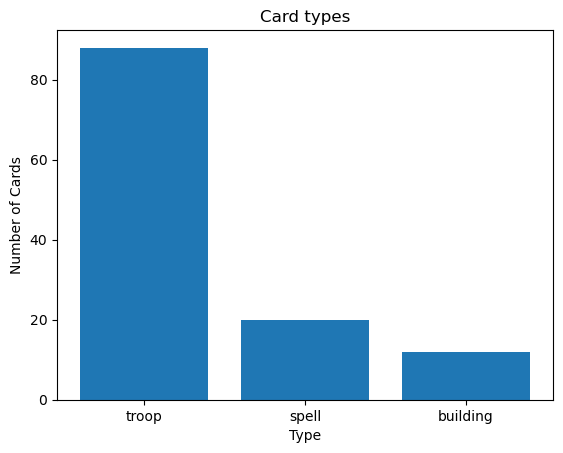

In [77]:
plt.bar(['troop', 'spell', 'building'], cards['type'].value_counts())
plt.title('Card types')
plt.xlabel('Type')
plt.ylabel('Number of Cards')
#plt.savefig('./graphs/card_types.png')
plt.show()

It appears that the majority of the cards are troop cards, whereas buildings and spells are rarer. This will be important for clustering later.

## Bivariate Analysis

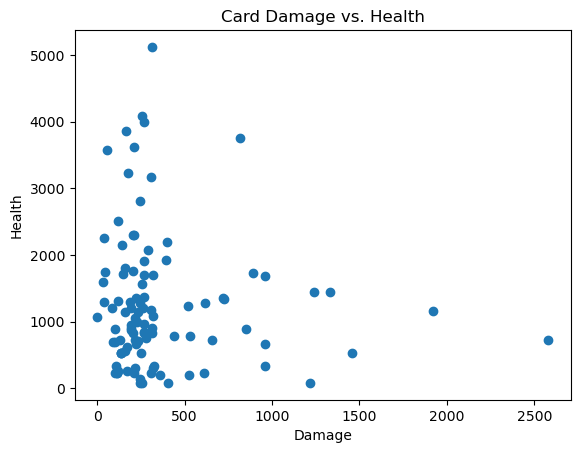

In [72]:
plt.scatter(cards['damage11'], cards['hitpoints11'])
plt.title('Card Damage vs. Health')
plt.xlabel('Damage')
plt.ylabel('Health')
#plt.savefig('./graphs/card_damage_vs_health.png')
plt.show()

High damage and high health rearely appear together in a card.

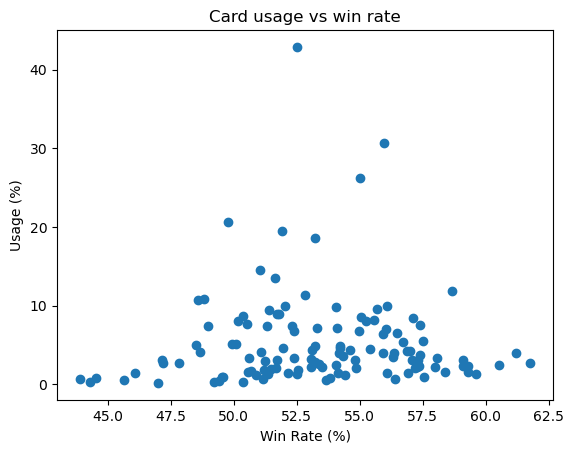

In [73]:
plt.scatter(y = cards['usage'], x = cards['Win Rate'])
plt.title('Card usage vs win rate')
plt.ylabel('Usage (%)')
plt.xlabel('Win Rate (%)')
#plt.savefig('./graphs/card_usage_vs_win_rate.png')
plt.show()

Higher usage rate evens out the win rate of a card, which makes sense as both skilled and unskilled players will play that card.

## Reload the Cleaned Deck Data

In [75]:
# Load data
decks = pd.read_csv('./data/decks.csv')
decks.head(5)

,card1,card2,card3,card4,card5,card6,card7,card8,wild,usage,Win Rate
0,Lumberjack,Balloon,Executioner,Skeleton Army,Skeletons,Freeze,The Log,Cannon,"['evo', 'hero', 'evo']",0.7,67.7
1,Battle Ram,Wizard,Royal Ghost,Giant Skeleton,Mother Witch,Vines,Zappies,Barbarian Barrel,"['evo', 'hero', 'evo']",0.5,67.6
2,Mortar,Goblins,Minion Horde,Miner,Cannon Cart,Skeleton Dragons,Rascals,Arrows,"['evo', 'hero', 'evo']",0.8,63.6
3,Skeleton Barrel,Goblins,Mortar,Cannon Cart,Fireball,Minions,Rascals,Barbarian Barrel,"['evo', 'hero', 'evo']",4.7,63.3
4,Skeleton Barrel,Bowler,Mortar,Fireball,Dart Goblin,Rascals,Skeletons,Barbarian Barrel,"['evo', 'hero', 'evo']",0.7,63.2


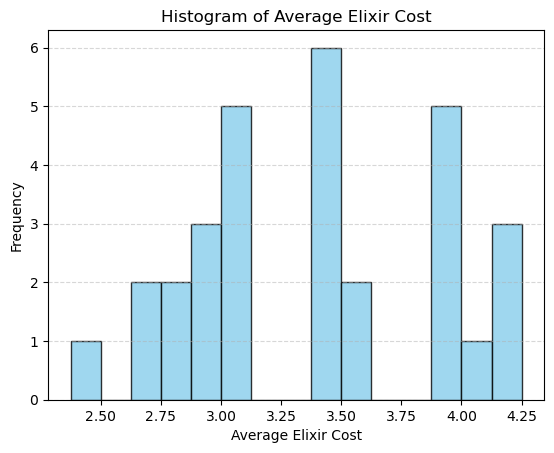

In [76]:
# Histogram of average elixir
elixir_map = dict(zip(cards['name'], cards['elixirCost']))
decks['avg_elixir'] = decks.iloc[:, :8].apply(lambda col: col.map(elixir_map)).mean(axis=1)

plt.hist(
    decks['avg_elixir'], bins=15, color='skyblue', edgecolor='black', alpha=0.8
)
plt.title('Histogram of Average Elixir Cost')
plt.xlabel('Average Elixir Cost')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.5)

#plt.savefig('./graphs/average_elixir_histogram.png', bbox_inches='tight')
plt.show()

It seems that the distribution of average elixir cost is roughly normal around $3.5$. The distribution is discrete as average elixir cost can only be integer multiples of $\frac{1}{8}$.

# Regression Modeling

Now we move on to using regression to predict the win rate of individual cards.

## Preparing Features

### Check for Nan Values

In [11]:
cards_orig = pd.read_csv('data/cards_cleaned.csv')

# Investigating missing values
print("Missing values per column:\n", cards_orig.isnull().sum())
print("\nRows with missing hitpoints11:\n", cards_orig[cards_orig['hitpoints11'].isnull()])
print("\nSpell cards:\n", cards_orig[cards_orig['type'] == 'spell'][['name', 'type', 'hitpoints11']])

Missing values per column:
 name            0
id              0
wild            0
elixirCost      0
rarity          0
damage11        0
hitpoints11    18
type            0
mobility        0
targets         0
attack_type     0
groupCard       0
usage           0
Win Rate        0
dtype: int64

Rows with missing hitpoints11:
                name        id    wild  elixirCost     rarity  damage11  \
98         Fireball  28000000  normal         4.0       rare     242.0   
99           Arrows  28000001  normal         3.0     common     294.0   
100            Rage  28000002  normal         2.0       epic     179.0   
101          Rocket  28000003  normal         6.0       rare    1484.0   
102   Goblin Barrel  28000004     evo         3.0       epic     360.0   
103          Freeze  28000005  normal         4.0       epic      41.0   
104       Lightning  28000007  normal         6.0       epic    1056.0   
105             Zap  28000008     evo         2.0     common     192.0   
106     

### Fill `hitpoints11` NaN With 0 For Spells (They Don't Have Hitpoints)

In [12]:
# Fill hitpoints11 NaN with 0 for spells (they don't have hitpoints)
cards_orig['hitpoints11'] = cards_orig['hitpoints11'].fillna(0)

# Verify no NaN remain
print(f"Remaining NaN values: {cards_orig.isnull().sum().sum()}")
print(f"hitpoints11 NaN count: {cards_orig['hitpoints11'].isnull().sum()}")

Remaining NaN values: 0
hitpoints11 NaN count: 0


### Categorical Feature Analysis

In [13]:
cards_orig['rarity'].value_counts()
cards_orig['type'].value_counts()
cards_orig['mobility'].value_counts()
cards_orig['targets'].value_counts()
cards_orig['attack_type'].value_counts()
cards_orig['groupCard'].value_counts()
cards_orig['wild'].value_counts()

wild
normal    72
evo       37
hero       8
both       3
Name: count, dtype: int64

### One-Hot Encoding Categorical Variables

In [18]:
# Creating dummy variables
cards = cards_orig.copy()

cards['rarity'] = cards['rarity'].map({
    'common': 0,
    'rare': 1,
    'epic': 2,
    'legendary': 3,
    'champion': 4
})

cards = pd.get_dummies(cards,
                       columns = ['wild', 'type', 'mobility', 'targets', 'attack_type', 'groupCard'],
                       dtype = int).drop(columns = 
    ['wild_normal', 'groupCard_False', 'attack_type_single', 'targets_ground', 'mobility_ground', 'type_troop']
)
cards.head()

,name,id,elixirCost,rarity,damage11,hitpoints11,usage,Win Rate,wild_both,wild_evo,wild_hero,type_building,type_spell,mobility_flying,targets_both,targets_buildings,attack_type_splash,groupCard_True
0,Knight,26000000,3.0,0,202.0,1766.0,8.88,51.79,1,0,0,0,0,0,0,0,0,0
1,Archers,26000001,3.0,0,214.0,304.0,1.44,46.10,0,1,0,0,0,0,1,0,0,1
2,Goblins,26000002,2.0,0,360.0,202.0,3.60,54.32,0,0,1,0,0,0,0,0,0,1
3,Giant,26000003,5.0,1,254.0,4090.0,2.32,59.10,0,0,1,0,0,0,0,1,0,0
4,P.E.K.K.A,26000004,7.0,2,816.0,3760.0,3.28,50.61,0,1,0,0,0,0,0,0,0,0


### Bivariate EDA - Feature Relationships

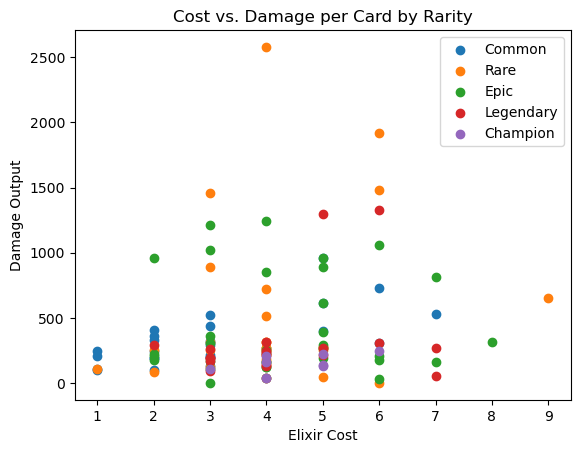

In [19]:
# Graphing bivariate relationships

rarities = ['Common', 'Rare', 'Epic', 'Legendary', 'Champion']
for i in np.arange(5):
    plt.scatter(x = cards.loc[cards['rarity'] == i]['elixirCost'],
                y = cards.loc[cards['rarity'] == i]['damage11'],
                label = rarities[i])
plt.title('Cost vs. Damage per Card by Rarity')
plt.xlabel('Elixir Cost')
plt.ylabel('Damage Output')
plt.legend()
plt.show()

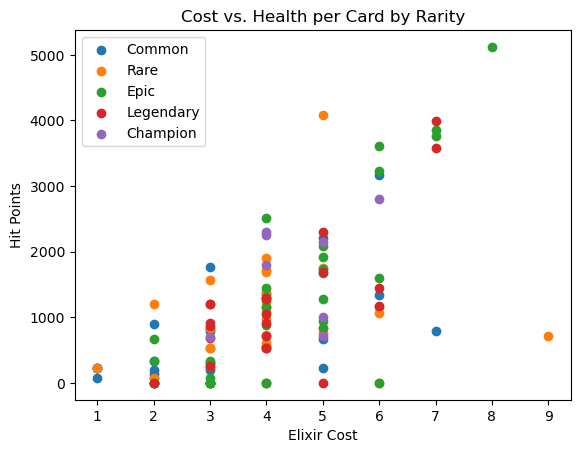

In [20]:
for i in np.arange(5):
    plt.scatter(x = cards.loc[cards['rarity'] == i]['elixirCost'],
                y = cards.loc[cards['rarity'] == i]['hitpoints11'],
                label = rarities[i])
plt.title('Cost vs. Health per Card by Rarity')
plt.xlabel('Elixir Cost')
plt.ylabel('Hit Points')
plt.legend()
plt.show()

## Logistic Regression

### Define Binary Outcome

In [21]:
# Use median as threshold
threshold = cards['Win Rate'].median()
cards['is_high_win'] = (cards['Win Rate'] > threshold).astype(int)

print(f"\nClass distribution using median threshold ({threshold:.3f}):")
print(cards['is_high_win'].value_counts())

# Target is already created
y = cards['is_high_win']


Class distribution using median threshold (53.260):
is_high_win
0    60
1    60
Name: count, dtype: int64


### Prepare Features

In [22]:
# Features
X = cards[['elixirCost', 'damage11', 'hitpoints11', 'usage', 
           'wild_both', 'wild_evo', 'wild_hero', 
           'type_building', 'type_spell', 
           'mobility_flying', 
           'targets_both', 'targets_buildings', 
           'attack_type_splash', 
           'groupCard_True']]

### Split Train/Test

In [23]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

### Scale Features

In [24]:
# Scale numerical columns
numerical_cols = ['elixirCost', 'damage11', 'hitpoints11', 'usage']
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test_scaled[numerical_cols] = scaler.transform(X_test[numerical_cols])

### Train Model

In [25]:
# Fit logistic regression
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

### Make Predictions

In [26]:
# Predict
y_pred = log_reg.predict(X_test_scaled)
y_pred_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

### Evaluate Performance

In [27]:
# Evaluate
y_pred = log_reg.predict(X_test_scaled)
y_pred_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba):.3f}")
print(f"\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.639
ROC-AUC: 0.712

Confusion Matrix:
[[17  9]
 [ 4  6]]

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.65      0.72        26
           1       0.40      0.60      0.48        10

    accuracy                           0.64        36
   macro avg       0.60      0.63      0.60        36
weighted avg       0.70      0.64      0.66        36



### Interpret Coefficients

In [28]:
# Feature importance
coefficients = pd.DataFrame({
    'feature': X.columns,
    'coefficient': log_reg.coef_[0],
    'odds_ratio': np.exp(log_reg.coef_[0])
})
coefficients = coefficients.sort_values('odds_ratio', ascending=False)

print("\n" + "="*60)
print("FEATURE IMPORTANCE (Highest to Lowest Impact)")
print("="*60)
print(coefficients.to_string(index=False))



FEATURE IMPORTANCE (Highest to Lowest Impact)
           feature  coefficient  odds_ratio
   mobility_flying     0.552426    1.737463
         wild_hero     0.366948    1.443322
    groupCard_True     0.161775    1.175596
       hitpoints11    -0.005973    0.994045
          damage11    -0.027470    0.972904
attack_type_splash    -0.141253    0.868270
             usage    -0.161576    0.850802
        elixirCost    -0.216563    0.805282
        type_spell    -0.289160    0.748893
      targets_both    -0.689966    0.501593
 targets_buildings    -0.713435    0.489958
         wild_both    -0.783304    0.456894
     type_building    -0.884476    0.412931
          wild_evo    -1.318258    0.267601


## Ridge Regression

In [29]:
# Ridge Regression with Cross-Validation
model1 = RidgeCV(alphas=[0.01, 0.1, 0.5, 1.0, 2.0, 2.25, 2.5, 2.75, 3.0, 3.5, 4.0, 5.0, 7.5, 10.0, 20.0, 30.0, 50.0])

# Train the model 
model1.fit(X_train_scaled, y_train)  # Use y_train, not y_sig

# Show results
print(f"Best alpha: {model1.alpha_}")
print("Coefficients:")
print(model1.coef_)

coef_df = pd.DataFrame({
    'feature': X.columns,
    'coefficient': model1.coef_
})
print("\nTop 3 features increasing win rate:")
print(coef_df.sort_values('coefficient', ascending=False).head(3))
print("\nTop 3 features decreasing win rate:")
print(coef_df.sort_values('coefficient', ascending=True).head(3))

Best alpha: 7.5
Coefficients:
[-0.04272694 -0.0086249   0.00648365 -0.03221312 -0.12248243 -0.25376818
  0.06193678 -0.1482637  -0.0496509   0.09474853 -0.119815   -0.1310251
 -0.04088676  0.03464882]

Top 3 features increasing win rate:
            feature  coefficient
9   mobility_flying     0.094749
6         wild_hero     0.061937
13   groupCard_True     0.034649

Top 3 features decreasing win rate:
              feature  coefficient
5            wild_evo    -0.253768
7       type_building    -0.148264
11  targets_buildings    -0.131025


## Lasso Regression

In [30]:
# Lasso Regression with Cross-Validation
model2 = LassoCV(alphas=[0.01, 0.025, 0.05, 0.075, 0.1, 0.5, 1.0, 10.0], random_state=42)

# Train the model
model2.fit(X_train_scaled, y_train)  # Use scaled features and original y_train

print(f"Best alpha: {model2.alpha_}")
print("Coefficients:")
print(model2.coef_)

# See which features survive (non-zero coefficients)
coef_df = pd.DataFrame({
    'feature': X.columns,
    'coefficient': model2.coef_
})
non_zero = coef_df[coef_df['coefficient'] != 0]
print(f"\nFeatures selected by Lasso: {len(non_zero)} out of {len(coef_df)}")
print(non_zero.sort_values('coefficient', ascending=False))

Best alpha: 10.0
Coefficients:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]

Features selected by Lasso: 0 out of 14
Empty DataFrame
Columns: [feature, coefficient]
Index: []


## Regression Results

### Logistic Regression

#### Scaling Numerical Features

In [31]:
# Scale only numerical columns, leave dummy variables as-is
numerical_cols = ['elixirCost', 'damage11', 'hitpoints11', 'usage']
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test_scaled[numerical_cols] = scaler.transform(X_test[numerical_cols])

#### 5-Fold Cross-Validation

In [32]:
# Use l1_ratio=0 for L2 penalty (same as penalty='l2')
model1 = LogisticRegression(l1_ratio=0, random_state=42)
model1.fit(X_train_scaled, y_train)  # Changed from X_scaled to X_train_scaled

# Cross-validation with proper scoring
scores = cross_val_score(model1, X_train_scaled, y_train, scoring='accuracy', cv=5)  # Changed
print(f"Cross-validation accuracy: {scores.mean():.3f} (+/- {scores.std()*2:.3f})")

Cross-validation accuracy: 0.607 (+/- 0.089)


#### ROC-AUC

In [33]:
# ROC-AUC
auc_scores = cross_val_score(model1, X_train_scaled, y_train, scoring='roc_auc', cv=5)  # Changed
print(f"Cross-validation ROC-AUC: {auc_scores.mean():.3f} (+/- {auc_scores.std()*2:.3f})")

Cross-validation ROC-AUC: 0.566 (+/- 0.176)


### Ridge Regression & Lasso Regression

#### Make Predictions

In [34]:
# Predict using scaled test data (same scaler used for training)
y_pred1 = model1.predict(X_test_scaled)
y_pred2 = model2.predict(X_test_scaled)

#### RMSE & R²

In [35]:
print("Ridge Regression:")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred1)):.3f}")
print(f"  R²: {r2_score(y_test, y_pred1):.3f}")

print("\nLasso Regression:")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred2)):.3f}")
print(f"  R²: {r2_score(y_test, y_pred2):.3f}")

Ridge Regression:
  RMSE: 0.601
  R²: -0.800

Lasso Regression:
  RMSE: 0.549
  R²: -0.502


#### Mean Error

In [36]:
print(f"Ridge mean error: {np.mean(y_pred1 - y_test):.5f}")
print(f"Lasso mean error: {np.mean(y_pred2 - y_test):.5f}")

Ridge mean error: 0.13889
Lasso mean error: 0.31746


From the mediocre results of regression, it is clear that a single card's stats alone does not define its win rate. Instead, it is how well that card works with other cards that determine its effectiveness. To investigate this, we must look at deck composition and synergies. To do so, we first need to categorize the cards.

# Card Clustering

## Load Card Data

In [39]:
# Load data
cards_df = pd.read_csv('./data/cards_cleaned.csv').fillna(0)
cards_df.head()

,name,id,wild,elixirCost,rarity,damage11,hitpoints11,type,mobility,targets,attack_type,groupCard,usage,Win Rate
0,Knight,26000000,both,3.0,common,202.0,1766.0,troop,ground,ground,single,False,8.88,51.79
1,Archers,26000001,evo,3.0,common,214.0,304.0,troop,ground,both,single,True,1.44,46.10
2,Goblins,26000002,hero,2.0,common,360.0,202.0,troop,ground,ground,single,True,3.60,54.32
3,Giant,26000003,hero,5.0,rare,254.0,4090.0,troop,ground,buildings,single,False,2.32,59.10
4,P.E.K.K.A,26000004,evo,7.0,epic,816.0,3760.0,troop,ground,ground,single,False,3.28,50.61
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,Royal Delivery,28000018,normal,3.0,common,437.0,787.0,spell,ground,both,splash,False,4.00,54.17
116,Void,28000023,normal,3.0,epic,1020.0,0.0,spell,ground,both,splash,False,0.80,53.83
117,Goblin Curse,28000024,normal,2.0,epic,210.0,0.0,spell,ground,both,splash,False,1.28,52.53
118,Spirit Empress,28000025,normal,6.0,legendary,307.0,1177.0,troop,flying,both,single,False,4.80,54.23


## Examine Card Data

In [41]:
# Interactive 3D scatterplot of numerical data, color-coded by its target type. Can toggle which datapoints to view by their target type via clicking on the legend.
fig = px.scatter_3d(
    cards_df,
    x='damage11',
    y='hitpoints11',
    z='elixirCost',
    color='targets',
    hover_name='name',
    hover_data=[
        'type',
        'rarity',
        'elixirCost',
    ],
    labels={
        'elixirCost': 'Elixir Cost',
        'damage11': 'Damage (Level 11)',
        'hitpoints11': 'Hitpoints (Level 11)',
        'targets': 'Target Type',
    },
    title='3D Scatter Plot of Cards (Colored by Target Type)',
    color_discrete_sequence=px.colors.qualitative.Bold,
)

fig.update_traces(
    marker=dict(
        size=5,
        opacity=0.8,
        line=dict(
            width=1, color='white'
        )
    )
)

fig.update_layout(margin=dict(l=0, r=0, b=0, t=50), width=1000, height=500)
#fig.write_html('./graphs/3d_scatter_plot_of_cards.html')
fig.show()

# all cards appear to be above the z=x+y plane

All cards appear to be above the z=x+y plane, consistent with the fact that high damage and high hitpoints do not come together. It also means that high damage or high hitpoints come at a cost of high elixir.

## Perform K-Prototype Clustering on Troop Cards

Since the data contains both numerical and categorical data, we use K-Prototype instead of K-means. We only cluster the troop cards, since buildings and spells have their own mechanics and there is not enough of them to cluster.

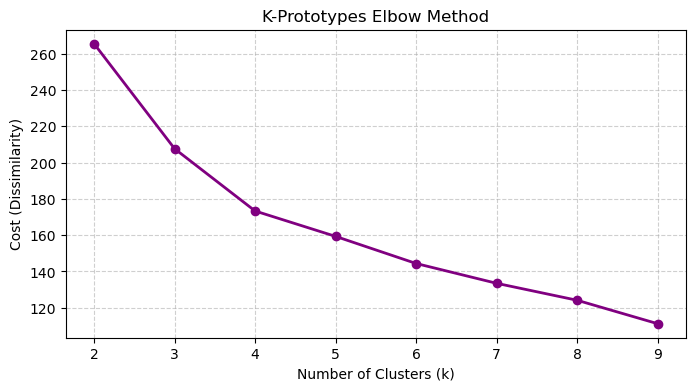

In [42]:
# Use K-prototypes instead of K-means for mixed data
numerical_cols = ['elixirCost', 'damage11', 'hitpoints11']
categorical_cols = ['wild', 'rarity', 'type', 'mobility', 'targets', 'attack_type', 'groupCard']

troops_clustering_df = cards_df.loc[cards_df['type']=='troop', numerical_cols + categorical_cols].copy()
scaler = StandardScaler()
troops_clustering_df[numerical_cols] = scaler.fit_transform(troops_clustering_df[numerical_cols])

clustering_matrix = troops_clustering_df.to_numpy()
cat_indices = [troops_clustering_df.columns.get_loc(col) for col in categorical_cols]

costs = []
k_range = range(2, 10)

for k in k_range:
    kproto = KPrototypes(n_clusters=k, init="Cao", random_state=67, n_init=5)
    kproto.fit(clustering_matrix, categorical=cat_indices)
    costs.append(kproto.cost_)

plt.figure(figsize=(8, 4))
plt.plot(k_range, costs, marker="o", color="purple", linewidth=2)
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Cost (Dissimilarity)")
plt.title("K-Prototypes Elbow Method")
plt.grid(True, linestyle="--", alpha=0.6)
plt.savefig('./graphs/kprototypes_elbow.png')
plt.show()

Judging from the dissimilarity graph of the clustering, the elbow appears to be at $k=4$, indicating that the optimal clustering is to group the troops into four clusters.

### Fit with $k=4$ Based on Elbow Method

In [43]:
# Fit optimal k
optimal_k = 4
kproto_final = KPrototypes(
    n_clusters=optimal_k, init="Cao", random_state=4, n_init=5
)

labels = kproto_final.fit_predict(clustering_matrix, categorical=cat_indices)
troops_clustered_df = cards_df.loc[cards_df['type']=='troop'].copy()
troops_clustered_df["Cluster"] = labels
troops_clustered_df = troops_clustered_df.sort_values(by="Cluster")

troops_clustered_df.head()

,name,id,wild,elixirCost,rarity,damage11,hitpoints11,type,mobility,targets,attack_type,groupCard,usage,Win Rate,Cluster
43,Elite Barbarians,26000043,normal,6.0,common,726.0,1341.0,troop,ground,ground,single,True,3.28,52.40,0
44,Hunter,26000044,evo,4.0,epic,848.0,885.0,troop,ground,both,single,False,1.52,50.58,0
58,Wall Breakers,26000058,evo,2.0,epic,962.0,330.0,troop,ground,buildings,single,True,7.12,54.09,0
18,Mini P.E.K.K.A,26000018,hero,4.0,rare,720.0,1361.0,troop,ground,ground,single,False,7.36,51.32,0
27,Dark Prince,26000027,normal,4.0,epic,1240.0,1440.0,troop,ground,ground,single,False,4.24,56.87,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38,Ice Golem,26000038,hero,2.0,rare,84.0,1198.0,troop,ground,ground,single,False,4.08,51.08,3
39,Mega Minion,26000039,hero,3.0,rare,311.0,837.0,troop,flying,both,single,False,3.28,58.08,3
113,Heal Spirit,28000016,normal,1.0,rare,110.0,230.0,troop,ground,both,splash,False,1.60,59.30,3
10,Skeletons,26000010,evo,1.0,common,243.0,81.0,troop,ground,ground,single,True,14.56,51.05,3


### Combine with Spells and Buildings

Since we omitted buildings and spells from the clustering earlier, we now add them back as clusters 4 and 5.

In [44]:
# Merge with spells and buildings
clustered_df = pd.concat([troops_clustered_df, cards_df.loc[cards_df['type']!='troop']])
clustered_df.loc[clustered_df['type']=='building', 'Cluster'] = optimal_k
clustered_df.loc[clustered_df['type']=='spell', 'Cluster'] = optimal_k+1
clustered_df['Cluster'] = clustered_df['Cluster'].astype(int).astype(str)
# clustered_df.to_csv('./data/cards_clustered.csv', index=False)
clustered_df.head()

,name,id,wild,elixirCost,rarity,damage11,hitpoints11,type,mobility,targets,attack_type,groupCard,usage,Win Rate,Cluster
43,Elite Barbarians,26000043,normal,6.0,common,726.0,1341.0,troop,ground,ground,single,True,3.28,52.40,0
44,Hunter,26000044,evo,4.0,epic,848.0,885.0,troop,ground,both,single,False,1.52,50.58,0
58,Wall Breakers,26000058,evo,2.0,epic,962.0,330.0,troop,ground,buildings,single,True,7.12,54.09,0
18,Mini P.E.K.K.A,26000018,hero,4.0,rare,720.0,1361.0,troop,ground,ground,single,False,7.36,51.32,0
27,Dark Prince,26000027,normal,4.0,epic,1240.0,1440.0,troop,ground,ground,single,False,4.24,56.87,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114,Giant Snowball,28000017,evo,2.0,common,192.0,0.0,spell,ground,both,splash,False,2.24,53.08,5
115,Royal Delivery,28000018,normal,3.0,common,437.0,787.0,spell,ground,both,splash,False,4.00,54.17,5
116,Void,28000023,normal,3.0,epic,1020.0,0.0,spell,ground,both,splash,False,0.80,53.83,5
117,Goblin Curse,28000024,normal,2.0,epic,210.0,0.0,spell,ground,both,splash,False,1.28,52.53,5


## Visualize & Interpret the Clusters

In [45]:
# Plot the clusters
fig = px.scatter_3d(
    clustered_df,
    x="damage11",
    y="hitpoints11",
    z="elixirCost",
    color="Cluster",
    hover_name="name",
    hover_data=[
        "type",
        "rarity",
        "targets",
        "Cluster",
    ],
    labels={
        "elixirCost": "Elixir Cost",
        "damage11": "Damage (Level 11)",
        "hitpoints11": "Hitpoints (Level 11)",
        "Cluster": "Cluster Group",
    },
    title="3D Scatter Plot of Cards Colored by Clusters",
    color_discrete_sequence=px.colors.qualitative.Bold,
)

fig.update_traces(
    marker=dict(
        size=5, opacity=0.8, line=dict(width=1, color="white")
    )
)

fig.update_layout(margin=dict(l=0, r=0, b=0, t=50), width=1000, height=500)
#fig.write_html('./graphs/3d_scatter_plot_of_card_clusters.html')
fig.show()

From the interactive 3D scatter plot, disabling (by clicking on the legend) the building and spell clusters allows us to clearly see the four troop clusters. It is apparent that cluster 0 is the highest in damage, thus are what is called "DPS" cards, specifically to deal damage at a high speed. Cluster 1 is very average in terms of health and elixir, thus are not quite tanks. Hence their name "mini-tank." Cluster 2 is very high in health, but at a cost of high elixir. Due to their high health, they are called "tanks." Cluster 3 is very low in both damage and health, but very cheap. In Clash Royale, the player only has access to four of his eight cards at a time, and thus needs to expend cards in order to draw their other cards. The player can choose cheap cards to expend cards faster; this is called cycling. Thus, cluster 3 is called "cycle" cards. Cluster 4 and 5 are "buildings" and "spells" respectively.

| Cluster | Card Type |
| :-----: | --------- |
| 0 | DPS |
| 1 | Mini-tank |
| 2 | Tank |
| 3 | Cycle |
| 4 | Building |
| 5 | Spell |

By hovering over the points in the scatter plot, the name and stats of the card will appear. There is an important card type in Clash Royale called the "win-condition," which seems to be missing from the clusters. A win-condition is a card in a deck that is dedicated to dealing damamge to the opponent's tower. However, win-conditions come in all shapes and sizes, such as the low-health wall-breakers to the high-health giant. Thus, win-condition is not a specific card type, but rather the role or function of a card within a system/deck. For instance, mega-knight can be a win-condition in some decks, but a defensive card in others.

# Deck Analysis

Now that we have clustered the cards into six different types, we can use that to analyze the top decks in competitive play.

## Load Deck Data

In [49]:
# Load Data
cards_df = pd.read_csv('./data/cards_clustered.csv')
decks_df = pd.read_csv('./data/decks.csv')

## Plot Deck Compositions

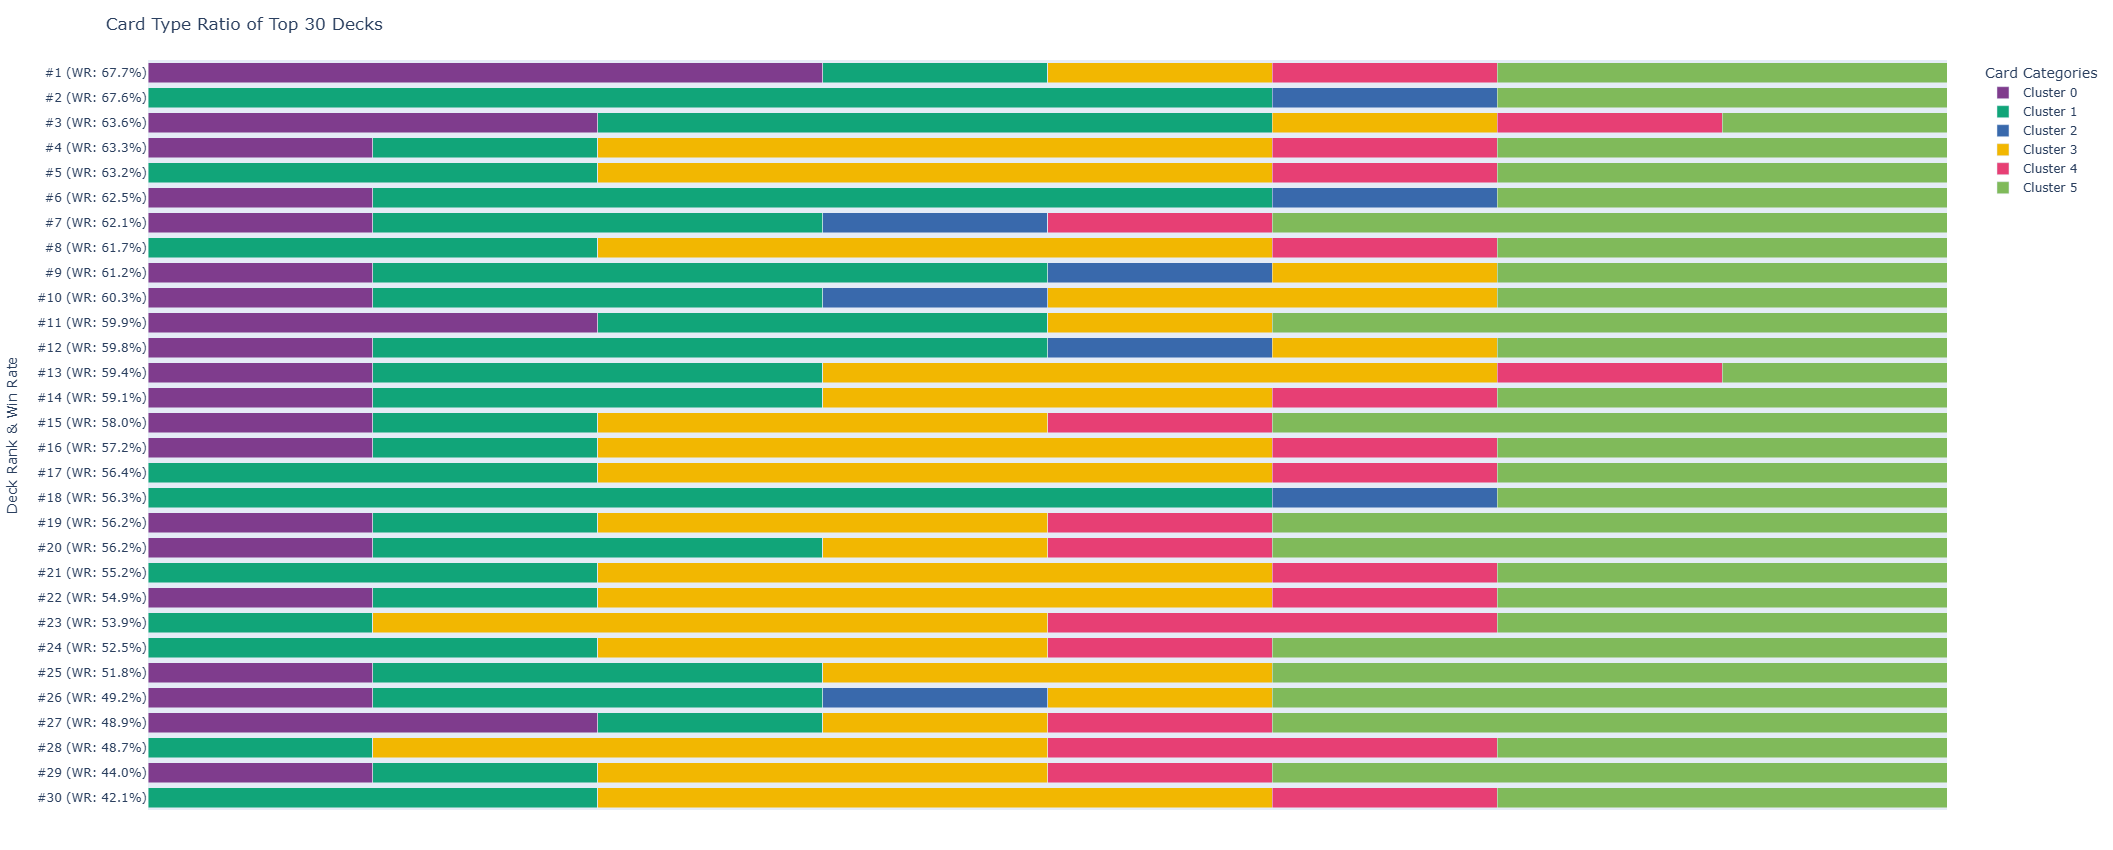

In [51]:
# Bar Chart of Deck Ratios
card_to_cluster = dict(zip(cards_df['name'], cards_df['Cluster']))
deck_clusters = decks_df.iloc[:, :8].map(lambda x: card_to_cluster.get(x, np.nan))

cluster_counts = deck_clusters.apply(lambda row: row.value_counts(), axis=1).fillna(0).astype(int)
cluster_counts = cluster_counts.reindex(columns=sorted(cluster_counts.columns))
cluster_counts.columns = [f"Cluster {int(c)}" for c in cluster_counts.columns]

cluster_ratios = cluster_counts.div(8)

decks_sorted = decks_df.sort_values(by='Win Rate', ascending=False).reset_index(drop=True)
cluster_ratios['Deck'] = [f"#{i+1} (WR: {row['Win Rate']}%)" for i, row in decks_sorted.iterrows()]

df_long = cluster_ratios.melt(id_vars='Deck', var_name='Cluster', value_name='Ratio')

fig = px.bar(
    df_long, 
    x='Ratio', 
    y='Deck', 
    color='Cluster', 
    orientation='h',
    title='Card Type Ratio of Top 30 Decks',
    labels={'Deck': 'Deck Rank & Win Rate'},
    category_orders={'Deck': cluster_ratios['Deck']} ,
    color_discrete_sequence=px.colors.qualitative.Bold
)

fig.update_layout(
    barmode='stack',
    height=850,
    xaxis=dict(visible=False, range=[0, 1]),
    margin=dict(l=120, r=40, t=60, b=40),
    legend_title_text='Card Categories',
    hovermode='y unified'
)

#fig.write_html('./graphs/card_type_ratio.html')
fig.show()

It seems that the most common card type is spells, which most decks have two or three of. Mini-tanks are prevalent in every deck, proving its versatility. Tanks and buildings are not so common, thus indicating that they are not as important.

## Hierarchical Clustering to Find Types of Decks

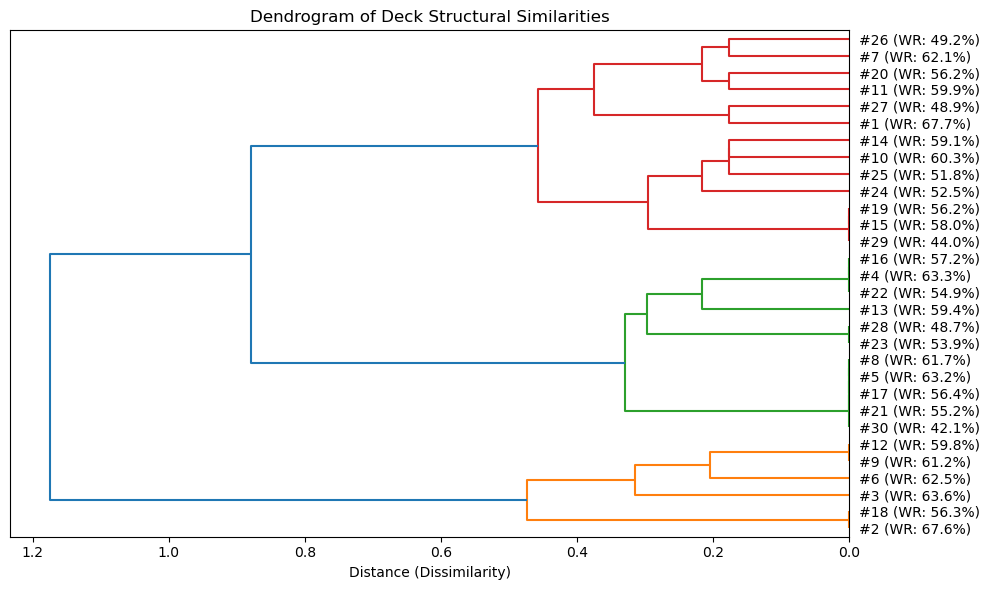

In [53]:
# Hierarchical clustering
features = cluster_ratios.drop(columns=['Deck'])

plt.figure(figsize=(10, 6))
dendrogram = sch.dendrogram(sch.linkage(features, method='ward'), 
                            labels=cluster_ratios['Deck'].tolist(),
                            orientation='left')

plt.title('Dendrogram of Deck Structural Similarities')
plt.xlabel('Distance (Dissimilarity)')
plt.tight_layout()
#plt.savefig('./graphs/deck_dendrogram.png')
plt.show()

The dendrogram is pretty, but does not reveal the card type proportions of its leaf nodes.

### Visualize the Types of Decks

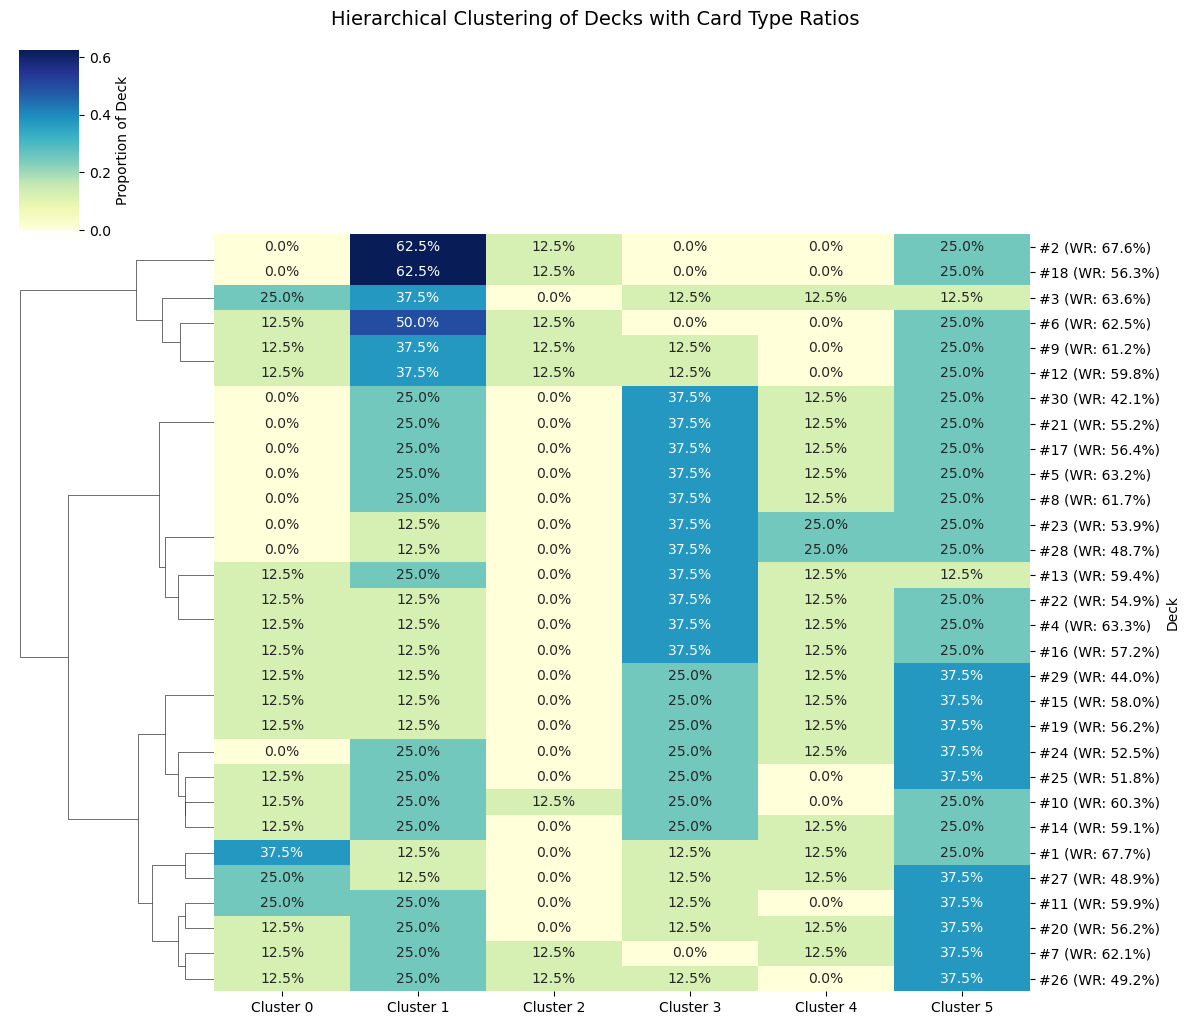

In [54]:
# 1. Prepare the data: Set the Deck labels as the index so they label the rows
heatmap_data = cluster_ratios.set_index('Deck')

# 2. Generate the clustermap
# We set col_cluster=False because we only want to cluster the decks (rows), 
# keeping your card clusters ordered sequentially (Cluster 0, 1, 2...).
g = sns.clustermap(
    heatmap_data,
    method='ward',
    metric='euclidean',
    col_cluster=False,       # Keeps your card clusters in order
    row_cluster=True,        # Clusters your 30 decks hierarchically
    cmap='YlGnBu',           # Consistent color palette
    annot=True,              # Injects the actual card ratio numbers into the grid
    fmt='.1%',               # Formats the grid numbers as percentages
    figsize=(12, 10),
    cbar_kws={'label': 'Proportion of Deck'}
)

# Adjust layout to prevent label clipping
plt.setp(g.ax_heatmap.get_yticklabels(), rotation=0)
g.fig.suptitle('Hierarchical Clustering of Decks with Card Type Ratios', y=1.02, fontsize=14)

#g.savefig('./graphs/deck_clustermap.png', bbox_inches='tight')
plt.show()

The top leaf node (decks 2 to 12) is very high in mini-tanks, which is indicative of what is known as a "bridge-spam" deck. Bridge-spam operates by placing a bunch of cards in the middle of the arena and overwhelming the opponent, thus requiring versatile cards that can both defend and attack. Hence why mini-tanks are very common in these decks. We can verify this by looking at the exact cards of some of the decks; deck 2 is a classic battle-ram bridge-spam deck, and deck 18 is a P.E.K.K.A bridge-spam deck. The middle leaf node (decks 30 to 16) is very high in cycle cards, thus are called "cycle" decks. These operate by trying to cycle cards fast enough to get their win-condition again before the opponent cycles to their counter. For instance, the infamous "Hog 2.6" deck is deck 17, notorious for its ability to cycle to the Hog Rider very quickly. The bottom leaf node (decks 29 to 26) is higher in spells and not so reliant on tanks, so either spell-bait decks or control decks.

## Examine Correlation Matrix

We can look at which types of cards appear together more often using a correlation matrix.

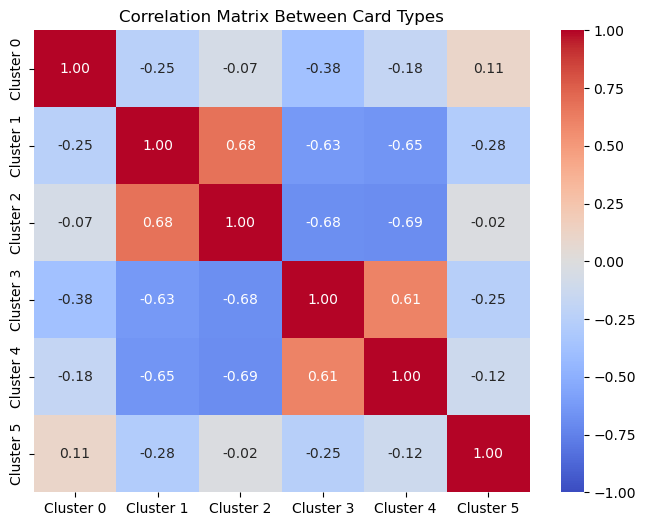

In [55]:
# Compute Pearson correlation between the different clusters
corr_matrix = cluster_ratios.drop(columns=['Deck']).corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title('Correlation Matrix Between Card Types')
#plt.savefig('./graphs/card_type_correlation.png')
plt.show()

It appears that mini-tanks and tanks are in the same deck often, possibly in beatdown decks where the tank needs the mini-tank's support. Cycle cards and buildings also appear together often, which makes sense since in cycle decks, buildings do the majority of the defending.

## Other Card Cluster Stats

In [56]:
# Examine standard deviation of card type ratios
cluster_variance = cluster_ratios.drop(columns=['Deck']).std().sort_values()
print("Cluster Stability (Lowest SD = Most Essential 'Core' Categories)")
print(cluster_variance)

Cluster Stability (Lowest SD = Most Essential 'Core' Categories)
Cluster 2    0.056222
Cluster 4    0.071040
Cluster 5    0.072912
Cluster 0    0.093330
Cluster 3    0.135679
Cluster 1    0.137258
dtype: float64


In [57]:
# Compare top 15 and bottom 15 deck ratios
top_half = cluster_ratios.iloc[:15].mean(numeric_only=True)
bottom_half = cluster_ratios.iloc[15:].mean(numeric_only=True)

comparison_df = pd.DataFrame({'Top 15 Decks Avg': top_half, 'Bottom 15 Decks Avg': bottom_half})
comparison_df['Difference'] = comparison_df['Top 15 Decks Avg'] - comparison_df['Bottom 15 Decks Avg']
print(comparison_df.sort_values(by='Difference', ascending=False))

           Top 15 Decks Avg  Bottom 15 Decks Avg  Difference
Cluster 1          0.291667             0.216667    0.075000
Cluster 0          0.133333             0.075000    0.058333
Cluster 2          0.050000             0.016667    0.033333
Cluster 4          0.075000             0.116667   -0.041667
Cluster 5          0.258333             0.308333   -0.050000
Cluster 3          0.191667             0.266667   -0.075000


## Box Plot of Deck Compositions

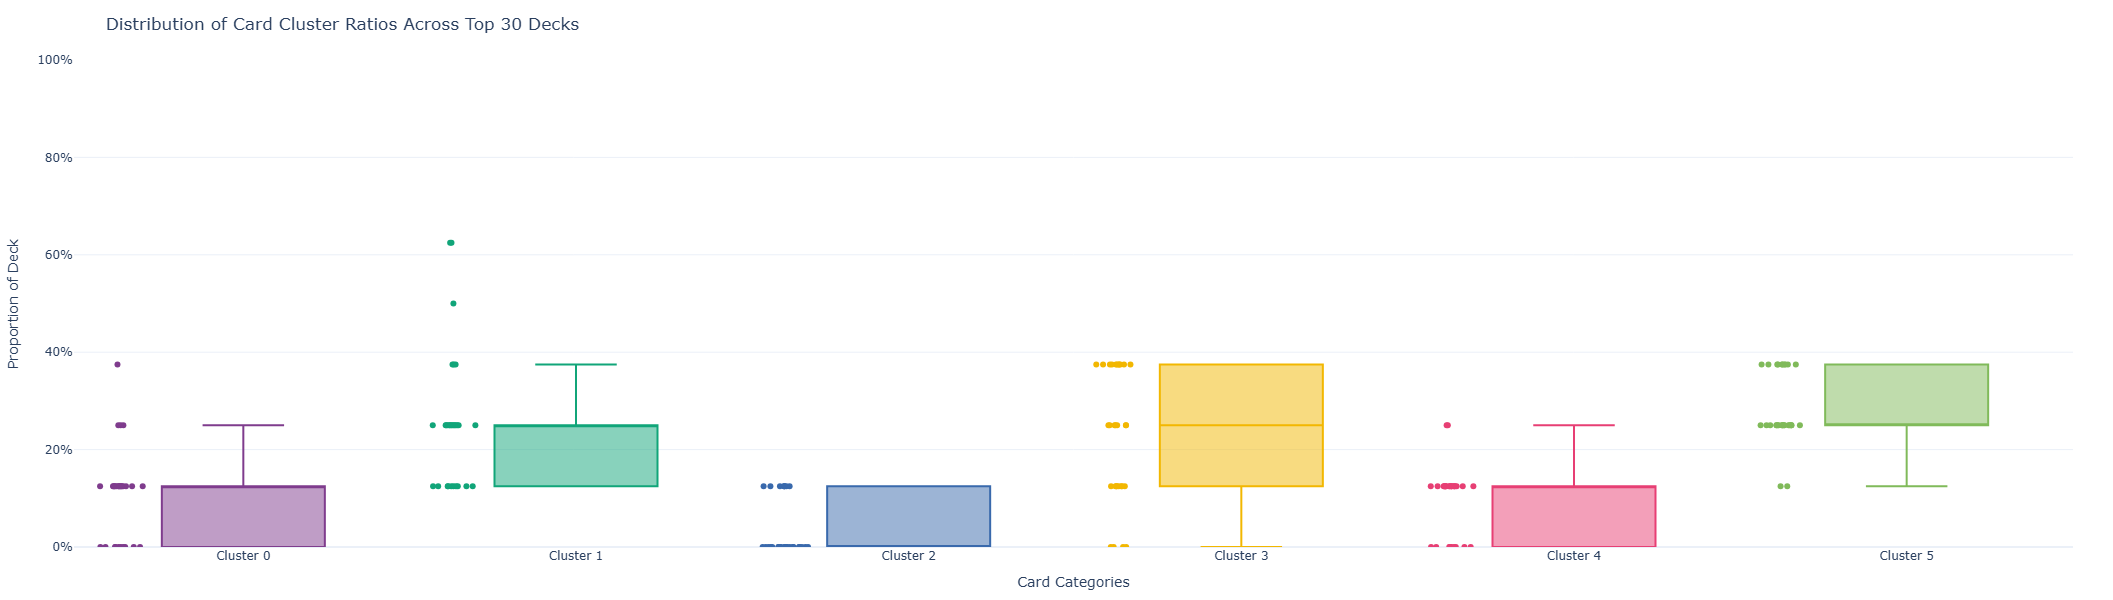

In [58]:
# Create the box plot using the long-form ratio data
fig = px.box(
    df_long,
    x='Cluster',
    y='Ratio',
    color='Cluster',
    points="all",
    title='Distribution of Card Cluster Ratios Across Top 30 Decks',
    labels={'Ratio': 'Proportion of Deck', 'Cluster': 'Card Categories'},
    color_discrete_sequence=px.colors.qualitative.Bold
)

fig.update_layout(
    yaxis_tickformat='.0%',
    yaxis=dict(range=[0, 1]),
    showlegend=False,
    height=600,
    margin=dict(l=60, r=40, t=60, b=40),
    template="plotly_white"
)

#plt.savefig('./graphs/card_type_ratio_box_plot.png')
fig.show()

## Bar Chart of Average Deck Composition

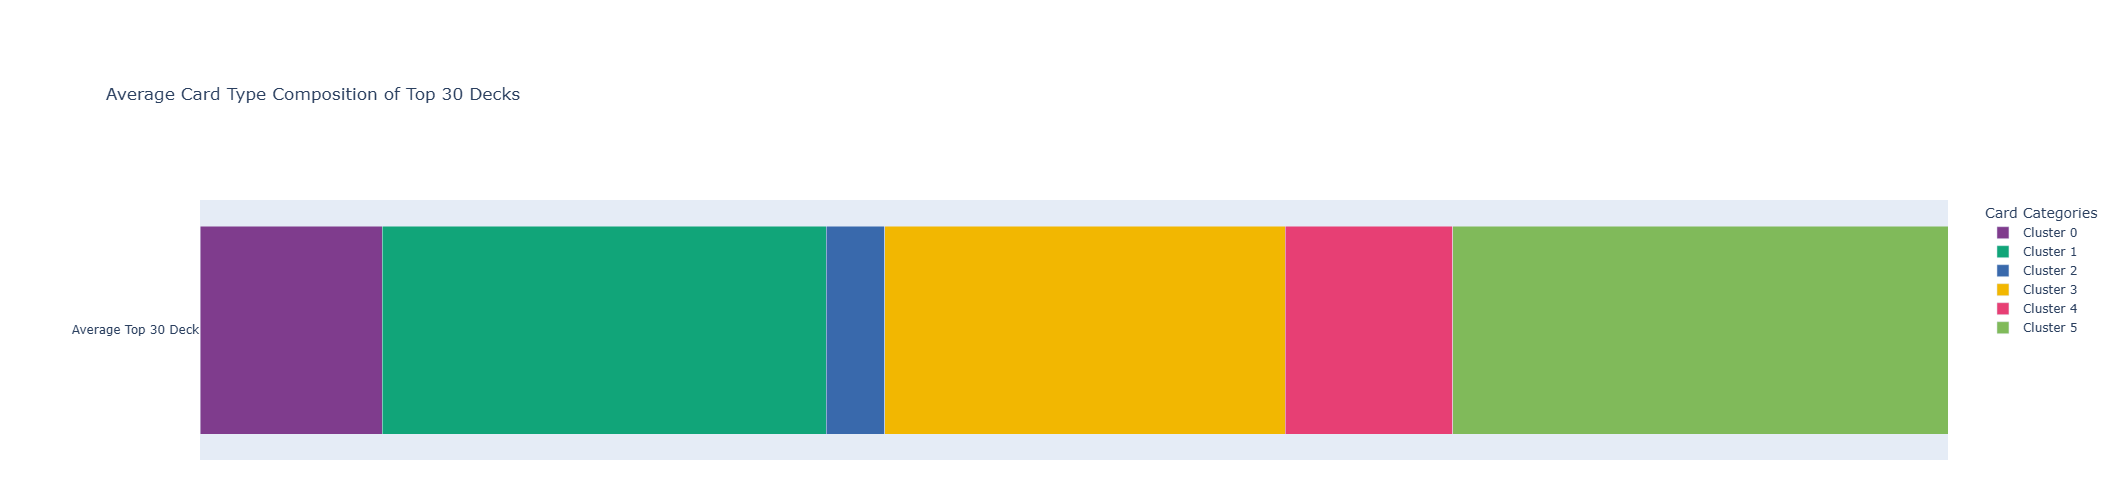

In [59]:
# Bar Chart of Averaged Deck Ratios (Single Horizontal Stacked Bar)
avg_ratios_series = cluster_ratios.iloc[:, :8].mean(numeric_only=True)

avg_df = pd.DataFrame([avg_ratios_series])

avg_df['Deck'] = "Average Top 30 Deck"

df_long = avg_df.melt(id_vars='Deck', var_name='Cluster', value_name='Ratio')

fig = px.bar(
    df_long, 
    x='Ratio', 
    y='Deck', 
    color='Cluster', 
    orientation='h',
    title='Average Card Type Composition of Top 30 Decks',
    labels={'Deck': ''},
    color_discrete_sequence=px.colors.qualitative.Bold
)

fig.update_layout(
    barmode='stack',
    height=500,
    xaxis=dict(visible=False, range=[0, 1]),
    margin=dict(l=200, r=40, t=200, b=40),
    legend_title_text='Card Categories',
    hovermode='y unified'
)

#fig.write_html('./graphs/average_card_type_ratio.html')
fig.show()

In conclusion, a good deck on average consists of at least two spells, has around two mini-tanks and one or two cycle cards. The rest of the cards are either DPS, tanks, or buildings.